**Instal EasyOCR**

In [1]:
!pip install easyocr

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 56.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.9/813.9 kB 52.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 kB 16.9 MB/s eta 0:00:00


**Import Package**

In [2]:
import cv2
import easyocr
from IPython.display import Image
import os

**Deteksi Plat**

In [3]:
folder_path = "./plat"
file_list = os.listdir(folder_path)

In [4]:
reader = easyocr.Reader(['id'])

for file_name in file_list:
    if file_name.endswith('.jpg'):  # Jika file adalah file gambar dengan ekstensi .jpg
        image_path = os.path.join(folder_path, file_name)
        Image(image_path)
        
        output = reader.readtext(image_path)
        print(file_name + ":")
        print(output)
        print("--------------------")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completescaned_img_11.jpg:
[([[62, 28], [238, 28], [238, 80], [62, 80]], '5012, fM]|', 0.17681389114255552)]
--------------------
scaned_img_7.jpg:
[([[140, 36], [376, 36], [376, 92], [140, 92]], '{AB 9383 . XBI', 0.28077597021406864)]
--------------------
scaned_img_12.jpg:
[([[22, 24], [176, 24], [176, 56], [22, 56]], 'B 4792 FCSI', 0.564011390819129)]
--------------------
scaned_img_0.jpg:
[([[81, 48], [317, 48], [317, 124], [81, 124]], 'BKs403 Agh', 0.5601137212621413)]
--------------------
scaned_img_13.jpg:
[([[187, 45], [207, 45], [207, 75], [187, 75]], 'B', 0.9814369012055977), ([[223, 39], [347, 39], [347, 79], [223, 79]], '1964 SSJ', 0.7466926600814875)]
--------------------
scaned_img_8.jpg:
[([[0, 23], [243, 23], [243, 83], [0, 83]], 'AB 5540 WE', 0.41257026332199365)]
--------------------
scaned_img_2.jpg:
[([[13, 15], [233, 15], [233, 81], [13, 81]], 'BK4758 AGB', 0.9631668879202417)]
------------------

**Teks Hasil Deteksi**

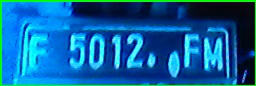

scaned_img_11.jpg:
5012, fM]|
--------------------


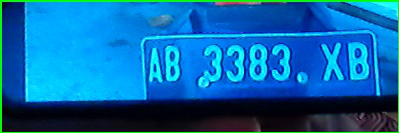

scaned_img_7.jpg:
{AB 9383 . XBI
--------------------


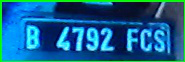

scaned_img_12.jpg:
B 4792 FCSI
--------------------


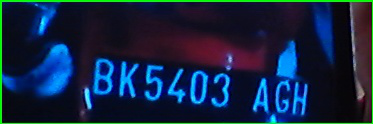

scaned_img_0.jpg:
BKs403 Agh
--------------------


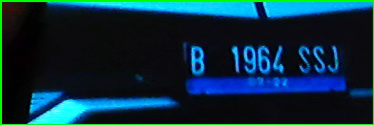

scaned_img_13.jpg:
B 1964 SSJ
--------------------


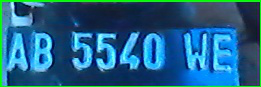

scaned_img_8.jpg:
AB 5540 WE
--------------------


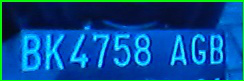

scaned_img_2.jpg:
BK4758 AGB
--------------------


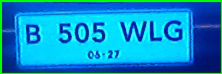

scaned_img_5.jpg:
B 505 WLG 08+27
--------------------


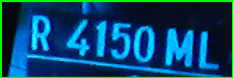

scaned_img_3.jpg:
R 4150ML
--------------------


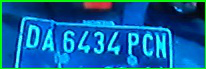

scaned_img_10.jpg:
DA 6437 PCM
--------------------


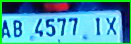

scaned_img_9.jpg:
AB 4577 1X
--------------------


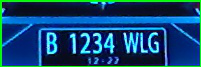

scaned_img_14.jpg:
B 1234 WLG
--------------------


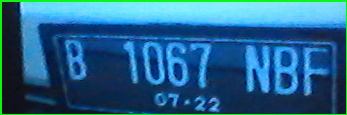

scaned_img_4.jpg:
1067  NBF] 4122
--------------------


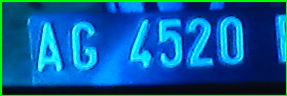

scaned_img_6.jpg:
Ag 4520
--------------------


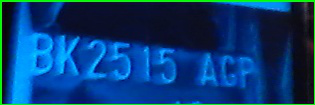

scaned_img_1.jpg:
PK2515 Acf
--------------------


In [5]:
import os
import easyocr
from PIL import Image

folder_path = "./plat"
file_list = os.listdir(folder_path)

reader = easyocr.Reader(['id'])

for file_name in file_list:
    if file_name.endswith('.jpg'):  # Jika file adalah file gambar dengan ekstensi .jpg
        image_path = os.path.join(folder_path, file_name)
        img = Image.open(image_path)
        display(img)

        output = reader.readtext(image_path)
        print(file_name + ":")
        combined_text = ""
        for item in output:
            combined_text += item[1] + " "
        print(combined_text.strip())
        print("--------------------")

**Menghitung Akurasi**

In [6]:
from difflib import SequenceMatcher

# Data referensi teks asli
reference_texts = {
    "scaned_img_2.jpg": "BK4758 AGB",
    "scaned_img_4.jpg": "1067 NBF",
    "scaned_img_9.jpg": "AB 4577 IX",
    "scaned_img_12.jpg": "B 4792 FCS",
    "scaned_img_5.jpg": "B 505 WLG",
    "scaned_img_0.jpg": "BK5403 AGH",
    "scaned_img_11.jpg": "F 5012 FM",
    "scaned_img_7.jpg": "AB 3383 XB",
    "scaned_img_6.jpg": "AG 4520 I",
    "scaned_img_14.jpg": "B 1234 WLG",
    "scaned_img_10.jpg": "DA 6434 PCN",
    "scaned_img_13.jpg": "B 1964 SSJ",
    "scaned_img_3.jpg": "B 4150 ML",
    "scaned_img_8.jpg": "AB 5540 WE",
    "scaned_img_1.jpg": "BK2515 AGP"
}

# Data output teks terdeteksi
output_texts = {
    "scaned_img_2.jpg": "BK4758 AGB",
    "scaned_img_4.jpg": "1067  NBF] 4122",
    "scaned_img_9.jpg": "AB 4577 1X",
    "scaned_img_12.jpg": "B 4792 FCSI",
    "scaned_img_5.jpg": "B 505 WLG 08+27",
    "scaned_img_0.jpg": "BKs403 Agh",
    "scaned_img_11.jpg": "5012, fM]",
    "scaned_img_7.jpg": "AB 9383 . XBI",
    "scaned_img_6.jpg": "Ag 4520",
    "scaned_img_14.jpg": "B 1234 WLG",
    "scaned_img_10.jpg": "DA 6437 PCM",
    "scaned_img_13.jpg": "B 1964 SSJ",
    "scaned_img_3.jpg": "R 4150ML",
    "scaned_img_8.jpg": "AB 5540 WE",
    "scaned_img_1.jpg": "PK2515 Acf"
}

# Fungsi untuk menghitung akurasi teks terdeteksi
def calculate_accuracy(reference_text, detected_text):
    matcher = SequenceMatcher(None, reference_text, detected_text)
    similarity_ratio = matcher.ratio()
    return similarity_ratio

# Menghitung akurasi untuk setiap data
for image_name in output_texts:
    reference_text = reference_texts.get(image_name, "")
    detected_text = output_texts[image_name]
    accuracy = calculate_accuracy(reference_text, detected_text)
    print(f"Image: {image_name}")
    print(f"Reference Text: {reference_text}")
    print(f"Detected Text: {detected_text}")
    print(f"Accuracy: {accuracy}\n")

Image: scaned_img_2.jpg
Reference Text: BK4758 AGB
Detected Text: BK4758 AGB
Accuracy: 1.0

Image: scaned_img_4.jpg
Reference Text: 1067 NBF
Detected Text: 1067  NBF] 4122
Accuracy: 0.6956521739130435

Image: scaned_img_9.jpg
Reference Text: AB 4577 IX
Detected Text: AB 4577 1X
Accuracy: 0.9

Image: scaned_img_12.jpg
Reference Text: B 4792 FCS
Detected Text: B 4792 FCSI
Accuracy: 0.9523809523809523

Image: scaned_img_5.jpg
Reference Text: B 505 WLG
Detected Text: B 505 WLG 08+27
Accuracy: 0.75

Image: scaned_img_0.jpg
Reference Text: BK5403 AGH
Detected Text: BKs403 Agh
Accuracy: 0.7

Image: scaned_img_11.jpg
Reference Text: F 5012 FM
Detected Text: 5012, fM]
Accuracy: 0.6666666666666666

Image: scaned_img_7.jpg
Reference Text: AB 3383 XB
Detected Text: AB 9383 . XBI
Accuracy: 0.782608695652174

Image: scaned_img_6.jpg
Reference Text: AG 4520 I
Detected Text: Ag 4520
Accuracy: 0.75

Image: scaned_img_14.jpg
Reference Text: B 1234 WLG
Detected Text: B 1234 WLG
Accuracy: 1.0

Image: scan

In [7]:
from difflib import SequenceMatcher

# Data referensi teks asli
reference_texts = {
    "scaned_img_2.jpg": "BK4758 AGB",
    "scaned_img_4.jpg": "1067 NBF",
    "scaned_img_9.jpg": "AB 4577 IX",
    "scaned_img_12.jpg": "B 4792 FCS",
    "scaned_img_5.jpg": "B 505 WLG",
    "scaned_img_0.jpg": "BK5403 AGH",
    "scaned_img_11.jpg": "F 5012 FM",
    "scaned_img_7.jpg": "AB 3383 XB",
    "scaned_img_6.jpg": "AG 4520 I",
    "scaned_img_14.jpg": "B 1234 WLG",
    "scaned_img_10.jpg": "DA 6434 PCN",
    "scaned_img_13.jpg": "B 1964 SSJ",
    "scaned_img_3.jpg": "B 4150 ML",
    "scaned_img_8.jpg": "AB 5540 WE",
    "scaned_img_1.jpg": "BK2515 AGP"
}

# Data output teks terdeteksi
output_texts = {
    "scaned_img_2.jpg": "BK4758 AGB",
    "scaned_img_4.jpg": "1067  NBF] 4122",
    "scaned_img_9.jpg": "AB 4577 1X",
    "scaned_img_12.jpg": "B 4792 FCSI",
    "scaned_img_5.jpg": "B 505 WLG 08+27",
    "scaned_img_0.jpg": "BKs403 Agh",
    "scaned_img_11.jpg": "5012, fM",
    "scaned_img_7.jpg": "AB 9383 . XBI",
    "scaned_img_6.jpg": "Ag 4520",
    "scaned_img_14.jpg": "B 1234 WLG",
    "scaned_img_10.jpg": "DA 6437 PCM",
    "scaned_img_13.jpg": "B 1964 SSJ",
    "scaned_img_3.jpg": "R 4150ML",
    "scaned_img_8.jpg": "AB 5540 WE",
    "scaned_img_1.jpg": "PK2515 Acf"
}

# Fungsi untuk menghitung akurasi teks terdeteksi
def calculate_accuracy(reference_text, detected_text):
    matcher = SequenceMatcher(None, reference_text, detected_text)
    similarity_ratio = matcher.ratio()
    return similarity_ratio

# Menghitung akurasi untuk setiap data
accuracies = []
for image_name in output_texts:
    reference_text = reference_texts.get(image_name, "")
    detected_text = output_texts[image_name]
    accuracy = calculate_accuracy(reference_text, detected_text)
    accuracies.append(accuracy)

# Menghitung akurasi rata-rata
average_accuracy = sum(accuracies) / len(accuracies)

# Menampilkan hasil akurasi secara keseluruhan
print(f"Overall Accuracy: {average_accuracy}")

Overall Accuracy: 0.8385490269889248
